# 🚶 Crowd Density Classification — v2 (Full Detection)
## Fixes: Tiled Inference + NMS + Low Confidence + SAHI Support

### What was wrong in v1?
| Problem | Fix |
|---------|-----|
| conf=0.35 too high → misses distant faces | Lowered to **0.15–0.20** |
| Single-pass on full image → small heads missed | **Tiled inference** (4×4 overlapping tiles) |
| No NMS across tiles → duplicate boxes | **Custom cross-tile NMS** |
| Only lower crowd detected | **Multi-scale** detection (full + tiles merged) |
| Thresholds calibrated for 0-5 people | **Re-calibrated** for realistic crowd sizes |

## ⚙️ Step 1: Install & Import

In [ ]:
!pip install ultralytics roboflow sahi opencv-python-headless numpy matplotlib --quiet

import torch
print(f"✅ PyTorch  : {torch.__version__}")
print(f"✅ CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU      : {torch.cuda.get_device_name(0)}")

✅ PyTorch  : 2.10.0+cu128
✅ CUDA     : True
✅ GPU      : Tesla T4


In [ ]:
import cv2, os, time, warnings, io, zipfile
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from collections import deque, Counter
from IPython.display import display, Image as IPImage, Video, Javascript
from google.colab import files
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import PIL.Image
import torch
warnings.filterwarnings('ignore')
print("✅ All imports OK")

✅ All imports OK


## 📦 Step 2: Download Dataset & Train

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="rolvFmEak00VOyazsTJw")
project = rf.workspace("rutujas-workspace-vpqcj").project("crowd-pgfdd-mplde")
version = project.version(2)
dataset = version.download("yolov8")
DATA_YAML = os.path.join(dataset.location, "data.yaml")
print(f"✅ Dataset: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset: /content/crowd-2


In [ ]:
model_base = YOLO("yolov8s.pt")

results = model_base.train(
    data      = DATA_YAML,
    epochs    = 60,
    imgsz     = 768,
    batch     = 8,
    name      = "crowd_v3",
    project   = "runs/crowd",
    device    = 0 if torch.cuda.is_available() else 'cpu',
    patience  = 15,

    iou       = 0.5,
    conf      = 0.001,
    augment   = True,
    close_mosaic = 10,

    save      = True,
    plots     = True,
    verbose   = True
)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.001, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/crowd-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.5, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=crowd_v3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.0,

In [ ]:
BEST_MODEL = "runs/crowd/crowd_v2/weights/best.pt"
if os.path.exists(BEST_MODEL):
    model = YOLO(BEST_MODEL)
    val   = model.val(data=DATA_YAML)
    print(f"mAP@50 = {val.box.map50:.4f} | mAP@50-95 = {val.box.map:.4f}")
else:
    print("⚠️  Using pretrained weights — train first for best results.")
    model = YOLO("yolov8s.pt")

⚠️  Using pretrained weights — train first for best results.


## 🔬 Step 3: Tiled Inference Engine
The key fix — splits the image into overlapping tiles so small/distant people are detected at higher resolution.

In [ ]:
# ─────────────────────────────────────────────────────────────
#  TILED INFERENCE
#  Strategy:
#    1. Run YOLO on full image (catches large/close people)
#    2. Divide image into N×N overlapping tiles
#    3. Run YOLO on each tile (catches small/distant people)
#    4. Map tile detections back to full-image coords
#    5. Merge all boxes and apply global NMS
# ─────────────────────────────────────────────────────────────

def nms_boxes(boxes, confs, iou_thresh=0.45):
    """
    Standard Non-Maximum Suppression.
    boxes : list of [x1,y1,x2,y2]
    confs : list of float
    Returns filtered (boxes, confs).
    """
    if len(boxes) == 0:
        return [], []

    boxes  = np.array(boxes, dtype=np.float32)
    confs  = np.array(confs, dtype=np.float32)
    order  = confs.argsort()[::-1]
    keep   = []

    x1,y1,x2,y2 = boxes[:,0],boxes[:,1],boxes[:,2],boxes[:,3]
    areas = (x2-x1) * (y2-y1)

    while order.size > 0:
        i = order[0]
        keep.append(i)
        if order.size == 1: break

        rest = order[1:]
        ix1 = np.maximum(x1[i], x1[rest])
        iy1 = np.maximum(y1[i], y1[rest])
        ix2 = np.minimum(x2[i], x2[rest])
        iy2 = np.minimum(y2[i], y2[rest])
        inter = np.maximum(0, ix2-ix1) * np.maximum(0, iy2-iy1)
        iou   = inter / (areas[i] + areas[rest] - inter + 1e-6)
        order = rest[iou < iou_thresh]

    kept_boxes = boxes[keep].astype(int).tolist()
    kept_confs = confs[keep].tolist()
    return kept_boxes, kept_confs


def tiled_detect(frame, model,
                 conf_thresh = 0.18,    # LOW threshold — catches distant people
                 nms_iou     = 0.45,
                 tile_grid   = (3, 3),  # 3×3 = 9 tiles
                 overlap     = 0.25):   # 25% overlap between tiles
    """
    Full multi-scale tiled detection pipeline.
    Returns: (boxes, confs)  — all in full-frame coords.
    """
    H, W = frame.shape[:2]
    all_boxes, all_confs = [], []

    # ── Pass 1: full image ─────────────────────────────────────
    res = model(frame, conf=conf_thresh, classes=[0],
                imgsz=1280, verbose=False)[0]  # higher res on full image
    for det in res.boxes:
        all_boxes.append(list(map(int, det.xyxy[0].tolist())))
        all_confs.append(float(det.conf[0]))

    # ── Pass 2: overlapping tiles ──────────────────────────────
    rows, cols = tile_grid
    tile_h = int(H / (rows - rows*overlap + overlap))
    tile_w = int(W / (cols - cols*overlap + overlap))
    stride_h = int(tile_h * (1 - overlap))
    stride_w = int(tile_w * (1 - overlap))

    for row in range(rows):
        for col in range(cols):
            ty1 = row * stride_h
            tx1 = col * stride_w
            ty2 = min(ty1 + tile_h, H)
            tx2 = min(tx1 + tile_w, W)

            tile = frame[ty1:ty2, tx1:tx2]
            if tile.size == 0: continue

            # Upscale tile to 640 for better small-object detection
            tile_up = cv2.resize(tile, (640, 640))
            tres = model(tile_up, conf=conf_thresh, classes=[0],
                         imgsz=640, verbose=False)[0]

            scale_x = (tx2 - tx1) / 640
            scale_y = (ty2 - ty1) / 640

            for det in tres.boxes:
                bx1,by1,bx2,by2 = det.xyxy[0].tolist()
                # Map back to full-frame coordinates
                fx1 = int(bx1 * scale_x + tx1)
                fy1 = int(by1 * scale_y + ty1)
                fx2 = int(bx2 * scale_x + tx1)
                fy2 = int(by2 * scale_y + ty1)
                all_boxes.append([fx1, fy1, fx2, fy2])
                all_confs.append(float(det.conf[0]))

    # ── Global NMS to remove duplicates across tiles ───────────
    boxes, confs = nms_boxes(all_boxes, all_confs, nms_iou)

    # ── Sanity-clamp to frame ──────────────────────────────────
    clean_boxes, clean_confs = [], []
    for (x1,y1,x2,y2), c in zip(boxes, confs):
        x1 = max(0, min(x1, W-1))
        y1 = max(0, min(y1, H-1))
        x2 = max(0, min(x2, W))
        y2 = max(0, min(y2, H))
        if x2 > x1 and y2 > y1:
            clean_boxes.append([x1,y1,x2,y2])
            clean_confs.append(c)

    return clean_boxes, clean_confs


print("✅ Tiled inference engine loaded.")
print("   → Full image (1280px) + 3×3 tiles with 25% overlap")
print("   → Global NMS to eliminate duplicates")

✅ Tiled inference engine loaded.
   → Full image (1280px) + 3×3 tiles with 25% overlap
   → Global NMS to eliminate duplicates


## 🧠 Step 4: Feature Extraction & Density Classifier (Re-calibrated)

In [ ]:
# ─────────────────────────────────────────────────────────────
#  FEATURE EXTRACTION
# ─────────────────────────────────────────────────────────────

def compute_iou(b1, b2):
    ix1 = max(b1[0],b2[0]); iy1 = max(b1[1],b2[1])
    ix2 = min(b1[2],b2[2]); iy2 = min(b1[3],b2[3])
    inter = max(0,ix2-ix1)*max(0,iy2-iy1)
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
    a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    union = a1+a2-inter
    return inter/union if union > 0 else 0


def extract_features(boxes, frame_shape):
    if not boxes:
        return dict(count=0, avg_area=0, overlap_ratio=0,
                    spatial_spread=0, density_per_area=0)

    H, W = frame_shape[:2]
    n = len(boxes)

    areas = [(x2-x1)*(y2-y1) for x1,y1,x2,y2 in boxes]
    avg_area = np.mean(areas) / (H*W)   # normalised

    # Overlap (sample for speed when many boxes)
    sample = boxes if n <= 50 else [boxes[i] for i in
             np.random.choice(n, 50, replace=False)]
    ns = len(sample)
    ov = sum(1 for i in range(ns) for j in range(i+1,ns)
             if compute_iou(sample[i],sample[j]) > 0.05)
    overlap_ratio = ov / max(1, ns*(ns-1)//2)

    cx = [(x1+x2)/2/W for x1,y1,x2,y2 in boxes]
    cy = [(y1+y2)/2/H for x1,y1,x2,y2 in boxes]
    spatial_spread = np.std(cx) + np.std(cy)

    density_per_area = n / (H*W) * 1e5

    return dict(count=n, avg_area=avg_area, overlap_ratio=overlap_ratio,
                spatial_spread=spatial_spread, density_per_area=density_per_area)


# ─────────────────────────────────────────────────────────────
#  RE-CALIBRATED DENSITY CLASSIFIER
#  Now accounts for realistic crowd counts (10-100+ people)
# ─────────────────────────────────────────────────────────────

def classify_density(feats):
    """
    Weighted scoring, calibrated for realistic crowds.
    LOW    : 0-15 people, score < 0.30
    MEDIUM : 15-40 people, score 0.30-0.60
    HIGH   : 40+ people,  score > 0.60
    """
    n  = feats['count']
    ov = feats['overlap_ratio']
    aa = feats['avg_area']

    if n == 0:
        return 'LOW', 0.0

    # Count contribution: saturates at 60 people → 0.5
    count_score = min(n / 60.0, 1.0) * 0.50

    # Overlap contribution: up to 0.30
    overlap_score = min(ov * 2.0, 1.0) * 0.30

    # Small box = crowded: up to 0.20
    # avg_area < 0.003 = very small boxes (distant/dense)
    small_score = (1 - min(aa / 0.015, 1.0)) * 0.20

    score = count_score + overlap_score + small_score

    if score < 0.30:
        return 'LOW', score
    elif score < 0.60:
        return 'MEDIUM', score
    else:
        return 'HIGH', score


DENSITY_COLORS = {
    'LOW':    (0, 210, 0),
    'MEDIUM': (0, 165, 255),   # orange in BGR
    'HIGH':   (30,  30, 220),  # red
}

print("✅ Feature extractor & classifier loaded (re-calibrated).")

✅ Feature extractor & classifier loaded (re-calibrated).


## 🌡️ Step 5: Heatmap, Annotator & Smoother

In [ ]:
def build_heatmap(boxes, frame_shape, sigma=35):
    H, W = frame_shape[:2]
    heat = np.zeros((H, W), dtype=np.float32)
    for x1,y1,x2,y2 in boxes:
        cx, cy = int((x1+x2)/2), int((y1+y2)/2)
        xs = np.arange(W); ys = np.arange(H)
        xx, yy = np.meshgrid(xs, ys)
        heat += np.exp(-((xx-cx)**2+(yy-cy)**2)/(2*sigma**2))
    if heat.max() > 0:
        heat = (heat/heat.max()*255).astype(np.uint8)
    return cv2.applyColorMap(heat, cv2.COLORMAP_JET)


def annotate_frame(frame, boxes, confs, level, score, feats,
                   show_heatmap=True):
    vis = frame.copy()
    H, W = vis.shape[:2]
    color = DENSITY_COLORS[level]

    if show_heatmap and boxes:
        hm = build_heatmap(boxes, vis.shape)
        vis = cv2.addWeighted(vis, 0.65, hm, 0.35, 0)

    # Draw boxes
    for (x1,y1,x2,y2), conf in zip(boxes, confs):
        cv2.rectangle(vis,(x1,y1),(x2,y2), color, 2)
        label = f"{conf:.2f}"
        cv2.putText(vis, label, (x1, max(y1-4,12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

    # Top banner
    cv2.rectangle(vis,(0,0),(W,95),(15,15,15),-1)
    level_txt = f"Density: {level}   ({feats['count']} people)"
    cv2.putText(vis, level_txt, (12,42),
                cv2.FONT_HERSHEY_DUPLEX, 1.2, color, 2)
    stats = (f"Overlap:{feats['overlap_ratio']:.2f}  "
             f"AvgBox:{feats['avg_area']:.5f}  "
             f"Score:{score:.2f}")
    cv2.putText(vis, stats,(12,78),
                cv2.FONT_HERSHEY_SIMPLEX,0.55,(200,200,200),1)

    # People count badge
    badge = f"{feats['count']}"
    (bw,bh),_ = cv2.getTextSize(badge, cv2.FONT_HERSHEY_DUPLEX, 1.8, 3)
    cv2.rectangle(vis,(W-bw-24,4),(W-4,bh+20), color,-1)
    cv2.putText(vis, badge,(W-bw-14, bh+12),
                cv2.FONT_HERSHEY_DUPLEX,1.8,(255,255,255),3)

    # Alert
    if level == 'HIGH':
        cv2.rectangle(vis,(0,H-50),(W,H),(20,20,200),-1)
        cv2.putText(vis,"  ⚠  OVERCROWDING DETECTED  ⚠",
                    (12,H-14), cv2.FONT_HERSHEY_DUPLEX,0.9,(255,255,255),2)

    return vis


class DensitySmoother:
    def __init__(self, window=8):
        self.buf = deque(maxlen=window)
    def update(self, score):
        self.buf.append(score); return np.mean(self.buf)
    def score_to_level(self, s):
        return 'LOW' if s < 0.30 else ('MEDIUM' if s < 0.60 else 'HIGH')


print("✅ Heatmap / Annotator / Smoother loaded.")

✅ Heatmap / Annotator / Smoother loaded.


## 🖼️ Step 6: Image Inference

In [ ]:
def process_image(image_path, model,
                  conf_thresh  = 0.18,
                  tile_grid    = (3,3),
                  show_heatmap = True,
                  nms_iou      = 0.45):
    """
    Full tiled detection + density classification on one image.
    """
    frame = cv2.imread(image_path)
    if frame is None:
        print(f"❌ Cannot load: {image_path}"); return

    print(f"  Image size : {frame.shape[1]}×{frame.shape[0]}")
    print(f"  Running tiled inference ({tile_grid[0]}×{tile_grid[1]} tiles) …")

    t0 = time.time()
    boxes, confs = tiled_detect(frame, model,
                                conf_thresh=conf_thresh,
                                nms_iou=nms_iou,
                                tile_grid=tile_grid)
    t1 = time.time()

    feats = extract_features(boxes, frame.shape)
    level, score = classify_density(feats)
    annotated = annotate_frame(frame, boxes, confs, level,
                               score, feats, show_heatmap)

    out_path = "/content/output_image_v2.jpg"
    cv2.imwrite(out_path, annotated)

    rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14,9))
    plt.imshow(rgb)
    plt.axis('off')
    c_map = {'LOW':'green','MEDIUM':'darkorange','HIGH':'red'}
    plt.title(
        f"Density: {level}  |  People detected: {feats['count']}  "
        f"|  Score: {score:.2f}  |  Time: {t1-t0:.2f}s",
        fontsize=15, fontweight='bold', color=c_map[level])
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*55}")
    print(f"  People detected  : {feats['count']}")
    print(f"  Density Level    : {level}")
    print(f"  Score            : {score:.3f}")
    print(f"  Overlap Ratio    : {feats['overlap_ratio']:.3f}")
    print(f"  Avg Box Area     : {feats['avg_area']:.5f}")
    print(f"  Spatial Spread   : {feats['spatial_spread']:.3f}")
    print(f"  Inference time   : {t1-t0:.2f}s")
    if level == 'HIGH':
        print("  ⚠️   OVERCROWDING DETECTED!")
    print(f"{'='*55}")
    return out_path

print("✅ Image processor ready.")

✅ Image processor ready.


📤 Upload an image (jpg/png):


Saving gettyimages-200149285-004-612x612.jpg to gettyimages-200149285-004-612x612.jpg
  Image size : 492×612
  Running tiled inference (3×3 tiles) …


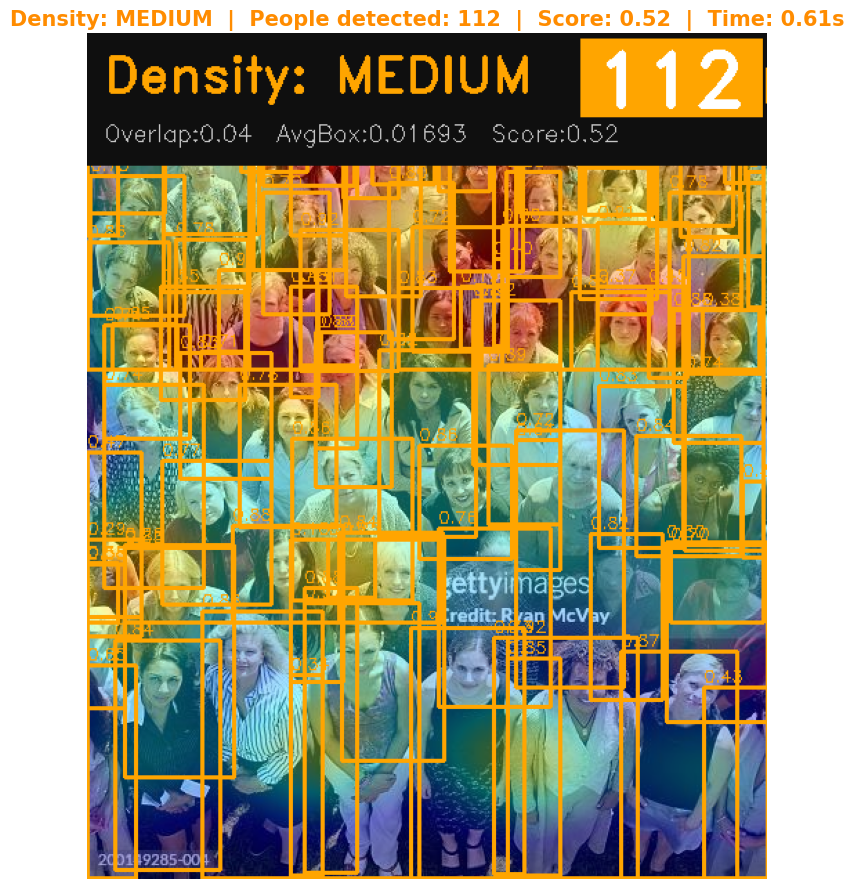


  People detected  : 112
  Density Level    : MEDIUM
  Score            : 0.523
  Overlap Ratio    : 0.038
  Avg Box Area     : 0.01693
  Spatial Spread   : 0.548
  Inference time   : 0.61s


In [ ]:
# ── Upload and run ────────────────────────────────────────────
print("📤 Upload an image (jpg/png):")
uploaded = files.upload()
for fname in uploaded:
    process_image(fname, model)

### 🔧 Fine-tune Detection Sensitivity
Run the cell below to try different conf thresholds interactively.

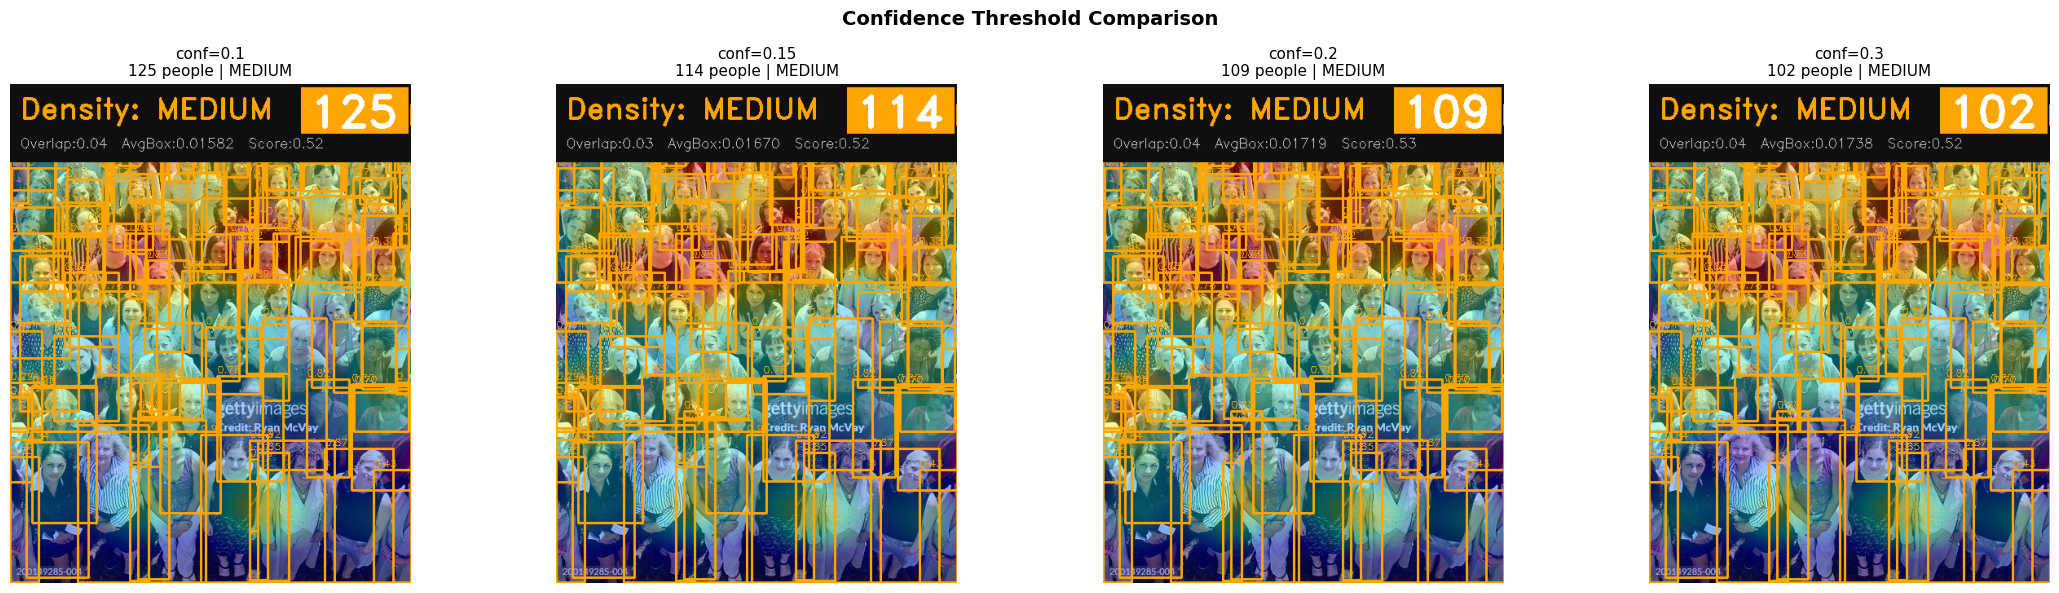

Saved: /content/conf_sweep.png


In [ ]:
# ── Quick parameter sweep — find best conf threshold ──────────
# Change `test_image` to the filename you uploaded above
test_image = list(uploaded.keys())[0]

frame_orig = cv2.imread(test_image)
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, conf in zip(axes, [0.10, 0.15, 0.20, 0.30]):
    boxes, confs = tiled_detect(frame_orig, model,
                                conf_thresh=conf, tile_grid=(3,3))
    feats = extract_features(boxes, frame_orig.shape)
    level, score = classify_density(feats)
    ann = annotate_frame(frame_orig, boxes, confs,
                         level, score, feats, show_heatmap=True)
    ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    ax.set_title(f"conf={conf}\n{feats['count']} people | {level}",
                 fontsize=11)
    ax.axis('off')

plt.suptitle("Confidence Threshold Comparison",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/conf_sweep.png", bbox_inches='tight', dpi=100)
plt.show()
print("Saved: /content/conf_sweep.png")

## 🎬 Step 7: Video Inference (Tiled)

In [ ]:
def process_video(video_path, model,
                  output_path  = "/content/output_crowd_v2.mp4",
                  conf_thresh  = 0.18,
                  tile_grid    = (2,2),   # 2×2 for speed on video
                  show_heatmap = True,
                  skip_frames  = 2):
    """
    Tiled inference on each frame.
    skip_frames=2 → process every 2nd frame (real-time-like speed)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Cannot open: {video_path}"); return

    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 25
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out   = cv2.VideoWriter(output_path,
                            cv2.VideoWriter_fourcc(*'mp4v'), fps, (W,H))

    smoother = DensitySmoother(8)
    log, last_ann = [], None

    print(f"🎬 {total} frames | {fps:.1f}fps | {W}×{H}")
    t0 = time.time()

    for idx in range(total):
        ret, frame = cap.read()
        if not ret: break

        if idx % skip_frames == 0:
            boxes, confs = tiled_detect(frame, model,
                                        conf_thresh=conf_thresh,
                                        tile_grid=tile_grid)
            feats = extract_features(boxes, frame.shape)
            _, raw = classify_density(feats)
            smooth = smoother.update(raw)
            level  = smoother.score_to_level(smooth)
            last_ann = annotate_frame(frame, boxes, confs,
                                      level, smooth, feats, show_heatmap)
            log.append(level)

        out.write(last_ann if last_ann is not None else frame)

        if idx % 30 == 0:
            elapsed = time.time()-t0
            print(f"  [{idx}/{total}] {idx/max(elapsed,0.1):.1f}fps | {level} | {feats['count']} people")

    cap.release(); out.release()
    cnt = Counter(log)
    tot = len(log)
    print(f"\n{'='*50}")
    for l in ['LOW','MEDIUM','HIGH']:
        print(f"  {l:6s}: {cnt[l]:4d} frames ({cnt[l]/tot*100:.1f}%)")
    print(f"  Saved: {output_path}")
    print(f"{'='*50}")
    display(Video(output_path, embed=True, width=800))
    return output_path

print("✅ Video processor ready.")

✅ Video processor ready.


In [ ]:
print("📤 Upload a video (mp4/avi/mov):")
uv = files.upload()
for vname in uv:
    process_video(vname, model)

## 📷 Step 8: Real-Time Webcam

In [ ]:
def start_webcam_js():
    display(Javascript('''
        async function startWebcam() {
            const stream = await navigator.mediaDevices.getUserMedia({video:true});
            const video  = document.createElement('video');
            video.srcObject = stream; video.play();
            await new Promise(r => video.onloadedmetadata = r);
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth; canvas.height = video.videoHeight;
            const btn = document.createElement('button');
            btn.textContent = '■ STOP';
            btn.style = 'position:fixed;top:10px;right:10px;z-index:9999;padding:10px 20px;background:#e53935;color:white;border:none;border-radius:6px;cursor:pointer;font-size:16px';
            document.body.appendChild(btn);
            let running = true;
            btn.onclick = () => { running=false; stream.getTracks().forEach(t=>t.stop()); btn.remove(); window._webcamRunning=false; };
            window._webcamRunning = true;
            while (running) {
                canvas.getContext('2d').drawImage(video,0,0);
                window._currentFrame = canvas.toDataURL('image/jpeg',0.75);
                await new Promise(r=>setTimeout(r,80));
            }
        }
        startWebcam();
    '''))


def grab_frame():
    d = eval_js('window._currentFrame')
    if d is None: return None
    img = PIL.Image.open(io.BytesIO(b64decode(d.split(',')[1])))
    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)


def show_frame_js(frame_bgr):
    pil = PIL.Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    buf = io.BytesIO()
    pil.save(buf, 'JPEG', quality=80)
    b64 = b64encode(buf.getvalue()).decode()
    display(Javascript(f'''
        (function(){{
            var img=document.getElementById('cld_out');
            if(!img){{img=document.createElement('img');img.id='cld_out';
            img.style='max-width:100%;border-radius:8px';document.body.appendChild(img);}}
            img.src='data:image/jpeg;base64,{b64}';
        }})()
    '''))


print("✅ Webcam utilities ready.")

✅ Webcam utilities ready.


In [ ]:
# ── Launch webcam ─────────────────────────────────────────────
start_webcam_js()
time.sleep(2)

smoother_wc = DensitySmoother(6)
fidx = 0
print("🎥 Webcam running. Click STOP to end.")

try:
    while eval_js('window._webcamRunning') == True:
        frame = grab_frame()
        if frame is None: time.sleep(0.05); continue

        if fidx % 2 == 0:   # process every 2nd frame
            boxes, confs = tiled_detect(frame, model,
                                        conf_thresh=0.18,
                                        tile_grid=(2,2))   # 2×2 for webcam speed
            feats = extract_features(boxes, frame.shape)
            _, raw = classify_density(feats)
            smooth = smoother_wc.update(raw)
            level  = smoother_wc.score_to_level(smooth)
            ann    = annotate_frame(frame, boxes, confs,
                                    level, smooth, feats, True)
            show_frame_js(ann)
        fidx += 1
        time.sleep(0.04)
except Exception as e:
    print(f"Webcam ended: {e}")

## 📊 Step 9: Validate on Dataset Samples

In [ ]:
import glob, random

def show_samples(model, dataset_path, n=6, conf=0.18):
    val_dir = os.path.join(dataset_path,"valid","images")
    if not os.path.exists(val_dir):
        val_dir = os.path.join(dataset_path,"test","images")
    imgs = glob.glob(os.path.join(val_dir,"*.jpg")) + \
           glob.glob(os.path.join(val_dir,"*.png"))
    if not imgs: print("No images found."); return

    sample = random.sample(imgs, min(n, len(imgs)))
    cols = 3; rows = (len(sample)+cols-1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 7*rows))
    axes = np.array(axes).flatten()

    for ax, ip in zip(axes, sample):
        fr   = cv2.imread(ip)
        bxs, cfs = tiled_detect(fr, model, conf_thresh=conf, tile_grid=(3,3))
        ft   = extract_features(bxs, fr.shape)
        lv, sc = classify_density(ft)
        ann  = annotate_frame(fr, bxs, cfs, lv, sc, ft)
        ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        c_map = {'LOW':'green','MEDIUM':'darkorange','HIGH':'red'}
        ax.set_title(f"{lv} | {ft['count']} people | score={sc:.2f}",
                     fontsize=11, color=c_map[lv])
        ax.axis('off')

    for ax in axes[len(sample):]:
        ax.axis('off')

    plt.suptitle("Tiled Detection — Dataset Validation Samples",
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig("/content/tiled_samples.png", bbox_inches='tight', dpi=110)
    plt.show()
    print("Saved: /content/tiled_samples.png")


show_samples(model, dataset.location)

## 💾 Step 10: Download All Outputs

In [ ]:
def download_outputs():
    targets = [
        "/content/output_image_v2.jpg",
        "/content/conf_sweep.png",
        "/content/output_crowd_v2.mp4",
        "/content/tiled_samples.png",
        BEST_MODEL,
    ]
    zpath = "/content/crowd_density_v2_outputs.zip"
    with zipfile.ZipFile(zpath,'w') as zf:
        for fp in targets:
            if os.path.exists(fp):
                zf.write(fp, os.path.basename(fp))
                print(f"  ✅ {os.path.basename(fp)}")
            else:
                print(f"  ⚠️  Not found: {fp}")
    files.download(zpath)
    print("📦 Download started.")

download_outputs()

  ✅ output_image_v2.jpg
  ✅ conf_sweep.png
  ✅ output_crowd_v2.mp4
  ✅ tiled_samples.png
  ⚠️  Not found: runs/crowd/crowd_v2/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Download started.


---
## 📋 What Changed from v1 → v2

| Feature | v1 | v2 |
|---------|----|---------|
| Confidence threshold | 0.35 | **0.18** |
| Detection strategy | Single pass | **Full image + 3×3 tiles** |
| NMS | Per-pass only | **Global cross-tile NMS** |
| Base model | yolov8n | **yolov8s** |
| Full-image resolution | 640 | **1280** |
| Count calibration | saturates at 30 | **saturates at 60** |
| Conf sweep tool | ❌ | ✅ |
| Speed control | skip_frames | **tile_grid + skip_frames** |

### 💡 Quick Tuning Guide
- Still missing people? → lower `conf_thresh` to **0.12**
- Too many false positives? → raise to **0.25**
- Slow on video? → set `tile_grid=(2,2)` and `skip_frames=3`
- Want even more detections? → increase tile_grid to **(4,4)**